# <span style="color:rgb(213,80,0)">Evaluación de las capacidades de un robot SCARA</span>

**Alumno:** Romeo Hernández Villa

**Profesor:**  M.I. Erik Peña Medina

**Asignatura:** Robótica

**Grupo:** 01


# **Resumen**
Este proyecto presenta el análisis, diseño y validación de una tarea de seguimiento de trayectoria para un robot SCARA (RRR). Se desarrolló un modelo matemático teórico utilizando MATLAB para calcular la cinemática inversa, velocidades (Jacobiano) y dinámica (Euler-Lagrange) bajo parámetros unitarios. Posteriormente, se validó el modelo mediante una simulación física en el entorno ROS 2 Jazzy con Gazebo Harmonic. Los resultados experimentales mostraron una coincidencia precisa en el perfil de posición y velocidad, confirmando la viabilidad de la trayectoria propuesta y la estabilidad del controlador implementado.


# **1. Introducción**

### 1.1. Objetivo del Proyecto
Evaluar las capacidades cinemáticas de un robot mediante el índice de manipulabilidad y determinar las características cinemáticas, dinámicas y de potencia de los actuadores del robot al ejecutar una tarea de seguimiento de trayectoria.

### 1.2. Hipótesis
Es posible evaluar las capacidades cinemáticas de un robot y determinar si este es capaz de realizar una tarea de seguimiento de una trayectoria simple mediante la comparación de un modelo teórico y una simulación física.

### 1.3. Descripción del Sistema
El sistema estudiado es un robot manipulador tipo SCARA con configuración RRR (tres articulaciones rotacionales). Para efectos de validación cruzada entre teoría y simulación, se definieron los siguientes parámetros físicos:
* **Longitudes:** $L_1 = 0.45$ m, $L_2 = 0.45$ m, $L_3 = 0.25$ m.
* **Dinámica:** Se utilizó un **Modelo Unitario** ($masa = 1$ kg, $Inercia = 1$ kg·m²) para estandarizar las pruebas y validar la física sin factores de escala externos.

## **2. Desarrollo (Parte teorica en MATLAB)**
### 2.1. Definición de la Tarea en el Espacio de Trabajo

Para evaluar las capacidades cinemáticas del robot SCARA en una región significativa de su volumen de trabajo, se propuso una tarea de seguimiento de trayectoria denominada **"Barrido Amplio"**. A diferencia de movimientos cortos o locales, esta trayectoria exige que el manipulador recorra una distancia considerable a través del plano transversal, coordinando simultáneamente la posición $(x, y)$ y la orientación $(\theta)$ del efector final.

<div align="center">
  <img src="imagenes/TRA.png" width="600" alt="Trayectoria Objetivo SCARA">
  <br>
  <i>Figura 0. Trayectoria objetivo propuesta para el análisis de capacidades cinemáticas y dinámicas del robot SCARA.</i>
</div>

Se definieron los puntos de control en el espacio cartesiano bajo los siguientes criterios de diseño:

1.  **Simetría y Amplitud:** El movimiento se realiza manteniendo la coordenada $x$ constante en $0.6$ m, mientras se realiza un barrido completo en el eje $y$ desde $0.5$ m hasta $-0.5$ m. Esto obliga a los actuadores de la base y el hombro a trabajar de manera coordinada para mantener la linealidad.

2.  **Reorientación del Efector:** Se incluyó una rotación de la herramienta desde $-\frac{\pi}{4}$ rad ($-45^\circ$) hasta $\frac{\pi}{4}$ rad ($+45^\circ$). Esto permite evaluar la capacidad del robot para desacoplar la orientación de la posición.

3.  **Verificación de Alcanzabilidad:** Antes de la ejecución, se verificó que los puntos propuestos se encuentren dentro del espacio de trabajo del robot. Considerando las longitudes de eslabón $L_1 = 0.45$ m y $L_2 = 0.45$ m, el alcance máximo es $R_{max} = 0.90$ m.
    * La distancia radial de los puntos propuestos es:
      $$R = \sqrt{0.6^2 + 0.5^2} \approx 0.781 \text{ m}$$
    * Dado que $0.781 \text{ m} < 0.90 \text{ m}$, la trayectoria es geométricamente viable y segura, dejando un margen de maniobra para evitar singularidades de frontera.

A continuación se presenta la definición de los puntos de control en el script de MATLAB:


In [1]:
% Definicion de los puntos (TRAYECTORIA PERSONALIZADA - BARRIDO AMPLIO)

% Pose inicial (Cuadrante Positivo Y, girado -45 grados)
x_in = 0.6;       % Reducimos un poco X para ganar rango en Y
y_in = 0.5;       % Empezamos más "arriba"
theta_in = -pi/4; % Orientación inicial inclinada (-0.78 rad)

% Pose final (Cuadrante Negativo Y, girado +45 grados)
x_fin = 0.6;      % Mantenemos X constante (movimiento vertical principal)
y_fin = -0.5;     % Terminamos "abajo" (simétrico)
theta_fin = pi/4; % Orientación final opuesta (+0.78 rad)

### 2.2. Cálculo de Cinemática Inversa (Configuración Inicial y Final)

Para determinar la configuración articular necesaria para alcanzar los puntos de inicio y fin definidos anteriormente, se implementó el modelo geométrico inverso del robot SCARA RRR. Dado que la orientación final del efector depende de la suma de los ángulos de las tres articulaciones, se utilizó el método de **Desacoplamiento Cinemático**.

Este método divide el problema en dos partes:
1.  **Localización de la Muñeca:** Se calcula la posición de la articulación 3 (la muñeca) restando el vector del último eslabón ($L_3$) a la posición deseada del efector final.
    $$x_3 = x - L_3 \cos(\theta_{global})$$
    $$y_3 = y - L_3 \sin(\theta_{global})$$

2.  **Resolución del Brazo Planar:** Con la posición de la muñeca ($x_3, y_3$) conocida, se resuelven los ángulos $\theta_1$ y $\theta_2$ utilizando la ley de cosenos para un mecanismo de dos eslabones:
    * **$\theta_2$ (Codo):**
        $$\theta_2 = \arccos\left( \frac{x_3^2 + y_3^2 - L_1^2 - L_2^2}{2 L_1 L_2} \right)$$
    * **$\theta_1$ (Hombro):**
        $$\theta_1 = \beta \pm \psi = \text{atan2}(y_3, x_3) \pm \arccos\left( \frac{x_3^2 + y_3^2 + L_1^2 - L_2^2}{2 L_1 \sqrt{x_3^2 + y_3^2}} \right)$$
    * **$\theta_3$ (Orientación):**
        $$\theta_3 = \theta_{global} - \theta_1 - \theta_2$$

El siguiente código realiza estos cálculos para los estados inicial ($P_{in}$) y final ($P_{fin}$), almacenando los ángulos límite que servirán para generar la trayectoria.

In [5]:
% Cálculo de la solución de la primer postura

% Definición de los parámetros del robot
L1 = 0.45; % Longitud del primer eslabón en base al URDF de robot scara
L2 = 0.45; % Longitud del segundo eslabón eslabón en base al URDF de robot scara
L3 = 0.25; % Longitud del tercer eslabón eslabón en base al URDF de robot scara

% Planteamiento de la solucion

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por le metodo geometrico

theta_2_in = acos((x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2));

beta = atan2(y_3,x_3);

psi = acos((x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2)));

theta_1_in = beta + psi;

% theta_1_in = beta - psi

theta_3_in = theta_in -theta_1_in - theta_2_in;

%%%
%% Solucion para el punto final

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por le metodo geometrico

theta_2_fin = acos((x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2));

beta = atan2(y_3,x_3);

psi = acos((x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2)));

theta_1_fin = beta + psi;

% theta_1_fin = beta - psi

theta_3_fin = theta_fin -theta_1_fin - theta_2_fin;


### 2.3. Generación de Perfil de Movimiento (Interpolación Polinómica)

Una vez obtenidos los valores articulares para las configuraciones inicial ($q_{in}$) y final ($q_{fin}$), es necesario definir cómo evolucionarán estos ángulos a lo largo del tiempo ($t$). Para garantizar un movimiento suave y evitar discontinuidades en la velocidad y aceleración (lo que provocaría vibraciones mecánicas y desgaste prematuro en los actuadores), se seleccionó un perfil de velocidad de **quinto grado** (Quintic Polynomial).

La función de interpolación utilizada es:

$$q(t) = q_{in} + \left( 10 \left(\frac{t}{t_f}\right)^3 - 15 \left(\frac{t}{t_f}\right)^4 + 6 \left(\frac{t}{t_f}\right)^5 \right) (q_{fin} - q_{in})$$

Donde:
* $t_f = 8.0$ s: Es el tiempo total asignado para la maniobra de "Barrido Amplio".
* Este polinomio satisface seis condiciones de frontera, asegurando que la posición, velocidad y aceleración sean cero tanto al inicio ($t=0$) como al final ($t=t_f$) del movimiento.

El siguiente código implementa este cálculo iterativo para cada una de las tres articulaciones ($\theta_1, \theta_2, \theta_3$):



### Planteamiento de una trayectoria en el espacio de las juntas del robot

Definición de la trayectoria


$$q =q_i +\lambda \left(t\right)\left(q_{\textrm{fin}} -q_{\textrm{in}} \right)$$


In [6]:
tf = 8;


for i=1:tf+1
    t = i-1; % Increment time for the next iteration
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end


### 2.4. Planeación en el Espacio de Trabajo (Trayectoria Cartesiana)

Adicionalmente, se implementó una estrategia de planificación en el **Espacio de Trabajo**. En este enfoque, en lugar de interpolar los ángulos de las articulaciones, se interpola la posición cartesiana $(x, y)$ y la orientación global $(\theta)$ del efector final utilizando el polinomio de quinto grado.

Esto garantiza que la punta del robot describa una línea recta perfecta en el plano $X-Y$ mientras reorienta la herramienta, lo cual es ideal para tareas de soldadura, corte o aplicación de adhesivos.

El algoritmo funciona de la siguiente manera para cada instante de tiempo $t$:
1.  Se calcula la coordenada deseada $x(t), y(t), \theta(t)$ usando el polinomio.
2.  Se resuelve el problema de **Cinemática Inversa** para ese punto específico.
3.  Se almacenan los ángulos resultantes en los vectores de trayectoria $\theta_{1\_tray}, \theta_{2\_tray}, \theta_{3\_tray}$.

El siguiente código de MATLAB realiza este cálculo iterativo para los $t_f = 8$ segundos:



### Planeación de trayectoria en el espacio de trabajo del robot


In [4]:
% Cálculo de la solución de la primer postura

% Definición de los parámetros del robot
L1 = 0.45; % Longitud del primer eslabón en base al URDF del robot scara
L2 = 0.45; % Longitud del segundo eslabón en base al URDF del robot scara
L3 = 0.25; % Longitud del tercer eslabón en base al URDF del robot scara

% x_in = 0.3;
% y_in = 0.3;
% theta_in = 0;

% x_fin = 0.3;
%y_fin = -0.3;
% theta_fin = pi/2;

tf = 8;
for i=1:tf+1
    t = i-1;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por le metodo geometrico

    theta_2_tray(i) = acos((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));

    beta = atan2(y_3_a(i),x_3_a(i));

    psi = acos((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));

    theta_1_tray(i) = beta + psi;

    % theta_1_in = beta - psi

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end


In [5]:
tsim=0:1:tf

tsim = 1x9
     0     1     2     3     4     5     6     7     8

### Análisis de la Trayectoria Articular Resultante

La siguiente gráfica muestra la evolución temporal de las coordenadas articulares ($\theta_1, \theta_2, \theta_3$) obtenida tras resolver la cinemática inversa paso a paso a lo largo de la trayectoria cartesiana planificada.

**¿Por qué es crítica esta gráfica?**

1.  **Validación de la Cinemática Inversa:** Confirma que el algoritmo de desacoplamiento cinemático y el método geométrico están generando valores continuos y coherentes. Si hubiera errores en las ecuaciones (como una raíz negativa o un `acos` fuera de rango), esta gráfica mostraría saltos abruptos o valores imaginarios.
2.  **Verificación de Suavidad:** Al utilizar un polinomio de quinto grado en el espacio de trabajo, se espera que los ángulos resultantes también cambien suavemente. 

 Las curvas "S" observadas confirman que no existen discontinuidades de velocidad que puedan dañar los actuadores.
 
3.  **Referencia de Control:** Estos perfiles angulares representan la "consigna" o *setpoint* ideal que el controlador del robot deberá seguir en la simulación física.

> **Nota Técnica sobre Coordenadas Articulares:**
> Es importante aclarar que las variables graficadas $\theta_1, \theta_2, \theta_3$ corresponden al **espacio de las juntas** (ángulos relativos) y no a la orientación absoluta de los eslabones en el mundo:
> * **$\theta_1$ (Hombro):** Ángulo relativo a la Base (Eje X del mundo).
> * **$\theta_2$ (Codo):** Ángulo relativo al Eslabón 1. Un valor de $\theta_2 = 0$ indica que el brazo está totalmente extendido (singularidad de frontera).
> * **$\theta_3$ (Muñeca):** Ángulo relativo al Eslabón 2, determinando la orientación final de la herramienta.

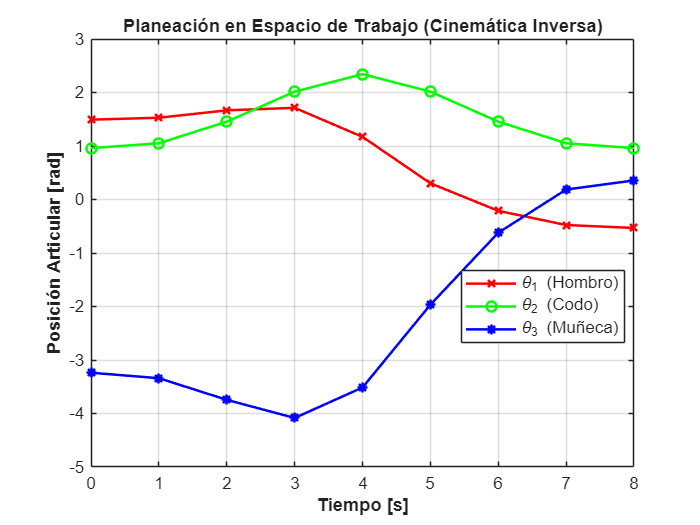

In [18]:
% --- GRÁFICA 1: RESULTADO DE CINEMÁTICA INVERSA ---
figure;

% Graficamos con estilo estándar 
plot(tsim, theta_1_tray, 'r-x', 'LineWidth', 1.5, 'MarkerSize', 6);
hold on;
plot(tsim, theta_2_tray, 'g-o', 'LineWidth', 1.5, 'MarkerSize', 6);
plot(tsim, theta_3_tray, 'b-*', 'LineWidth', 1.5, 'MarkerSize', 6);

hold off;


% Leyenda con nombres estandarizados y renderizado 
legend({'\theta_1 (Hombro)', '\theta_2 (Codo)', '\theta_3 (Muñeca)'}, ...
    'Location', 'best', 'Interpreter', 'tex', 'FontSize', 10);

% Títulos y Ejes con formato negrita
title('Planeación en Espacio de Trabajo (Cinemática Inversa)', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Posición Articular [rad]', 'FontWeight', 'bold');

% Ajustes visuales finales
grid on;
xlim([0, tf]);
set(gca, 'FontSize', 10); % Hace los números de los ejes más legibles

### Perfil de Posición Articular Planificado

La siguiente gráfica ilustra la evolución temporal de las variables articulares ($\theta_1, \theta_2, \theta_3$) generada mediante la interpolación polinómica de quinto grado. Estas curvas representan las consignas de posición (*setpoints*) que los controladores del robot deben seguir.

**Importancia de esta gráfica:**

1.  **Verificación de Continuidad:** Se observa que las curvas son suaves y continuas ($C^2$), sin cambios bruscos de pendiente. Esto confirma que la velocidad y la aceleración no presentan discontinuidades, evitando vibraciones mecánicas.
2.  **Condiciones de Frontera:** Se puede validar visualmente que las curvas inician y terminan con pendiente cero (velocidad nula), cumpliendo con los requisitos de seguridad para el arranque y paro del robot.
3.  **Rango de Movimiento:** Permite visualizar la magnitud del desplazamiento de cada articulación, identificando cuál motor realizará el mayor recorrido angular.

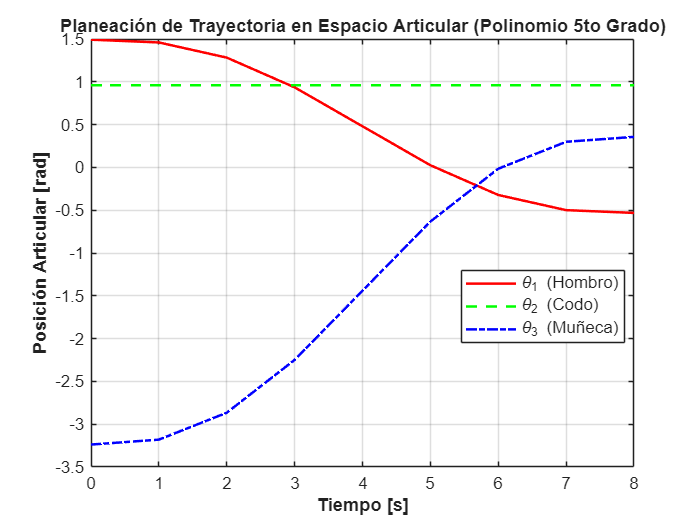

In [20]:
% --- GRÁFICA 2: PLANEACIÓN ARTICULAR (ÁNGULOS) ---
figure;

% Graficamos 
plot(tsim, theta_1_P, 'r-', 'LineWidth', 1.5);
hold on;
plot(tsim, theta_2_P, 'g--', 'LineWidth', 1.5); % Guiones
plot(tsim, theta_3_P, 'b-.', 'LineWidth', 1.5); % Punto y raya
hold off;


% 1. Leyenda 
legend({'\theta_1 (Hombro)', '\theta_2 (Codo)', '\theta_3 (Muñeca)'}, ...
    'Location', 'best', 'Interpreter', 'tex', 'FontSize', 10);

% 2. Títulos y Ejes 
title('Planeación de Trayectoria en Espacio Articular (Polinomio 5to Grado)', ...
    'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Posición Articular [rad]', 'FontWeight', 'bold');

% 3. Ajustes visuales
grid on;
xlim([0, tf]); % Ajuste exacto al tiempo de simulación
set(gca, 'FontSize', 10); 

In [8]:

% w = L1*L2*sin(theta_2)

### 2.5. Modelo Cinemático de Velocidad

Para determinar la velocidad angular requerida en cada articulación ($\dot{\theta}$), se obtuvo la primera derivada temporal del polinomio de posición de quinto grado. La ecuación resultante describe un perfil de velocidad en forma de campana:

$$\dot{q}(t) = \frac{d}{dt}q(t) = \left( \frac{30t^2}{t_f^3} - \frac{60t^3}{t_f^4} + \frac{30t^4}{t_f^5} \right) (q_{fin} - q_{in})$$

**Justificación del Perfil:**
* **Arranque y Paro Suave:** La ecuación garantiza que $\dot{q}(0) = 0$ y $\dot{q}(t_f) = 0$, lo que significa que el robot inicia y termina su movimiento en reposo absoluto.
* **Continuidad:** La función es continua en todo el intervalo, asegurando que los motores no sufran cambios bruscos de voltaje.

El siguiente código implementa este cálculo:

### **Calculo de la cinemática de velocidades del robot**
### *Cinemática de velocidades en espacio de las juntas*


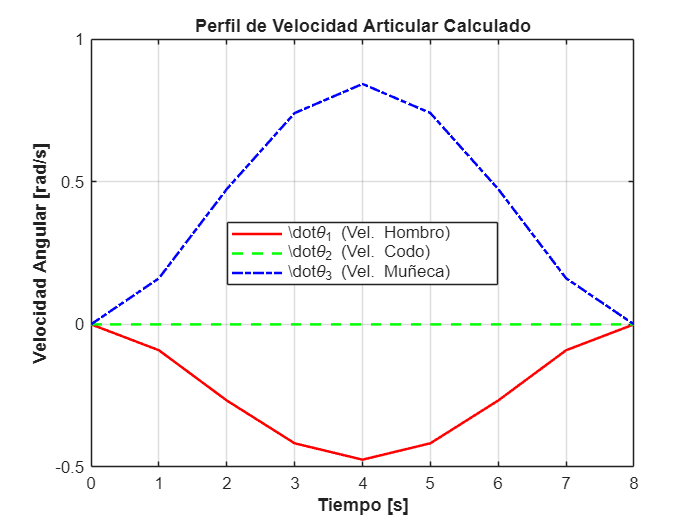

In [22]:
tf = 8;

% Inicializar vectores para velocidad
theta_1_P_v = zeros(1, tf+1);
theta_2_P_v = zeros(1, tf+1);
theta_3_P_v = zeros(1, tf+1);

for i = 1 : tf + 1
    t = i - 1; % Empezar en t=0

    % Polinomio de Velocidad (Derivada del de posición)
    poly_vel = (30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4;

    theta_1_P_v(i) = poly_vel * (theta_1_fin - theta_1_in);
    theta_2_P_v(i) = poly_vel * (theta_2_fin - theta_2_in);
    theta_3_P_v(i) = poly_vel * (theta_3_fin - theta_3_in);
end

% --- GRÁFICA 3: PERFIL DE VELOCIDAD  ---
figure;

% Graficamos
plot(tsim, theta_1_P_v, 'r-', 'LineWidth', 1.5); hold on;
plot(tsim, theta_2_P_v, 'g--', 'LineWidth', 1.5);
plot(tsim, theta_3_P_v, 'b-.', 'LineWidth', 1.5);
hold off;


% Usamos \dot{\theta} para que aparezca el símbolo theta con el punto de velocidad
legend({'\dot{\theta}_1 (Vel. Hombro)', '\dot{\theta}_2 (Vel. Codo)', '\dot{\theta}_3 (Vel. Muñeca)'}, ...
    'Location', 'best', 'Interpreter', 'tex', 'FontSize', 10);

% Etiquetas y Títulos
title('Perfil de Velocidad Articular Calculado', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Velocidad Angular [rad/s]', 'FontWeight', 'bold');

% Ajustes visuales
grid on;
xlim([0, tf]);
set(gca, 'FontSize', 10);

### 2.6. Modelo Cinemático de Aceleración

Finalmente, para estimar los requerimientos dinámicos del sistema, se obtuvo la segunda derivada temporal del perfil de posición. Esto nos entrega la aceleración angular ($\ddot{\theta}$) que cada motor debe suministrar para cumplir con la trayectoria.

La ecuación del perfil de aceleración derivada del polinomio de quinto grado es:

$$\ddot{q}(t) = \frac{d^2}{dt^2}q(t) = \left( \frac{60t}{t_f^3} - \frac{180t^2}{t_f^4} + \frac{120t^3}{t_f^5} \right) (q_{fin} - q_{in})$$

**Importancia de este Perfil:**
1.  [cite_start]**Suavidad Mecánica:** A diferencia de un perfil trapezoidal (que tiene saltos de aceleración), este polinomio garantiza que la aceleración inicie en 0 y termine en 0. Esto elimina el **Jerk** (golpes mecánicos) al arranque y al frenado.
2.  **Estimación de Par (Torque):** Dado que el par requerido es proporcional a la aceleración ($\tau \approx J \ddot{q}$), esta gráfica nos permite predecir la forma de onda que tendrán los torques en el análisis dinámico.

El siguiente código implementa el cálculo y visualización de estas aceleraciones:

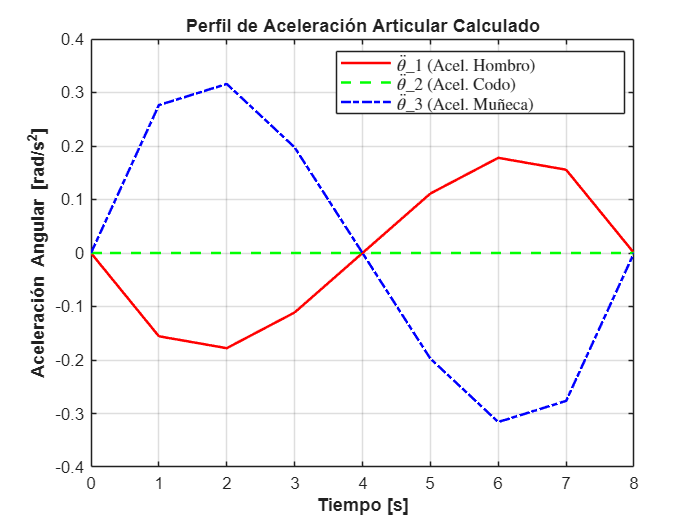

In [23]:
tf = 8;

% Inicializar vectores para aceleración
theta_1_P_a = zeros(1, tf+1);
theta_2_P_a = zeros(1, tf+1);
theta_3_P_a = zeros(1, tf+1);

for i = 1 : tf + 1
    t = i - 1; % Empezar en t=0

    % Polinomio de Aceleración (Segunda derivada del de posición)
    poly_accel = (60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3;

    theta_1_P_a(i) = poly_accel * (theta_1_fin - theta_1_in);
    theta_2_P_a(i) = poly_accel * (theta_2_fin - theta_2_in);
    theta_3_P_a(i) = poly_accel * (theta_3_fin - theta_3_in);
end

% --- GRÁFICA 4: PERFIL DE ACELERACIÓN  ---
figure;

% Graficamos
plot(tsim, theta_1_P_a, 'r-', 'LineWidth', 1.5); hold on;
plot(tsim, theta_2_P_a, 'g--', 'LineWidth', 1.5);
plot(tsim, theta_3_P_a, 'b-.', 'LineWidth', 1.5);
hold off;


% Usamos \ddot{\theta} (doble punto) para indicar Aceleración Angular
legend({'\ddot{\theta}_1 (Acel. Hombro)', '\ddot{\theta}_2 (Acel. Codo)', '\ddot{\theta}_3 (Acel. Muñeca)'}, ...
    'Location', 'best', 'Interpreter', 'latex', 'FontSize', 10);

% Etiquetas y Títulos
title('Perfil de Aceleración Articular Calculado', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Aceleración Angular [rad/s^2]', 'FontWeight', 'bold');

% Ajustes visuales
grid on;
xlim([0, tf]);
set(gca, 'FontSize', 10);

### 2.7. Cinemática Diferencial Inversa (Jacobiano)

Para validar la consistencia del modelo, se calculó la velocidad articular requerida ($\dot{q}$) partiendo de la velocidad deseada en el espacio de trabajo ($\dot{x}, \dot{y}, \dot{\phi}$) mediante la matriz Jacobiana Inversa.

La relación fundamental es:
$$\dot{q} = J^{-1}(q) \cdot \nu$$

Donde:
* $\nu = [\dot{x}, \dot{y}, \dot{\phi}]^T$ es el vector de velocidades cartesianas, obtenido derivando el polinomio de interpolación en el espacio de trabajo.
* $J^{-1}(q)$ es la matriz Jacobiana inversa dependiente de la configuración actual del robot.

Al implementar las ecuaciones analíticas del Jacobiano Inverso para el robot SCARA y multiplicarlas por la velocidad de la trayectoria, se obtienen los perfiles de velocidad articular. **Estos perfiles deben ser idénticos a los obtenidos por derivación directa**, sirviendo como una doble comprobación matemática del modelo.

### **Cinemática de velocidades en espacio de trabajo**


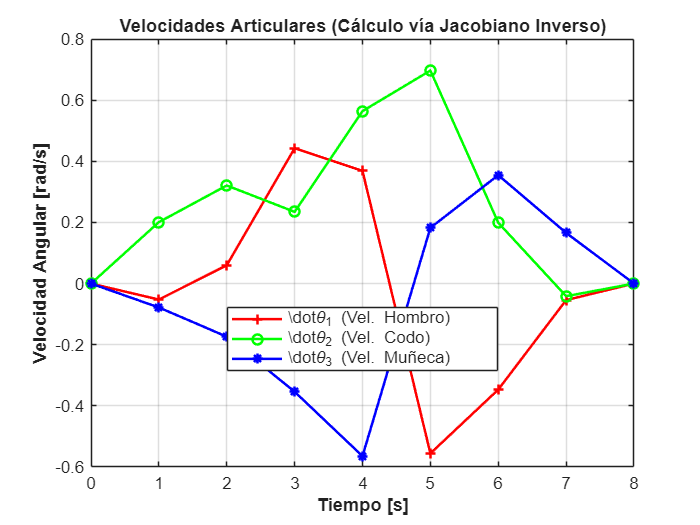

In [25]:
%% CINEMÁTICA DE VELOCIDADES EN ESPACIO DE TRABAJO (JACOBIANO INVERSO)

% 1. Definición de parámetros reales (robot SCARA)
L_1 = 0.45;
L_2 = 0.45;
L_3 = 0.25;

% Definir tiempo (Aseguramos que sea el mismo de arriba)
tf = 8;

% Inicializar vectores
x_P_v = zeros(1, tf+1);
y_P_v = zeros(1, tf+1);
theta_P_v = zeros(1, tf+1);
theta_1_v = zeros(1, tf+1);
theta_2_v = zeros(1, tf+1);
theta_3_v = zeros(1, tf+1);

% 2. Bucle de Cálculo
for i = 1 : tf + 1
    t = i - 1; % Empezar en 0

    % Velocidades Cartesianas Deseadas (Derivada del Polinomio)
    poly_vel = (30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4;

    x_P_v(i) = poly_vel * (x_fin - x_in);
    y_P_v(i) = poly_vel * (y_fin - y_in);
    theta_P_v(i) = poly_vel * (theta_fin - theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    % Recuperar ángulos de la trayectoria cartesiana (Calculados previamente)
    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    % --- ECUACIONES DEL JACOBIANO INVERSO ---
    % J1
    term1 = (x_dot * cos(theta_1_2 + theta_O_1)) / (L_1 * sin(theta_1_2));
    term2 = (y_dot * sin(theta_1_2 + theta_O_1)) / (L_1 * sin(theta_1_2));
    term3 = (L_3 * theta_dot_P * sin(theta_2_3)) / (L_1 * sin(theta_1_2));
    theta_1_v(i) = term1 + term2 + term3;

    % J2 (Fórmula larga )
    num_A = x_dot * (L_2 * cos(theta_1_2 + theta_O_1) + L_1 * cos(theta_O_1));
    num_B = y_dot * (L_2 * sin(theta_1_2 + theta_O_1) + L_1 * sin(theta_O_1));
    num_C = L_3 * theta_dot_P * (L_1 * sin(theta_1_2 + theta_2_3) + L_2 * sin(theta_2_3));
    den = L_1 * L_2 * sin(theta_1_2);

    theta_2_v(i) = -(num_A / den) - (num_B / den) - (num_C / den);

    % J3
    term_J3_1 = (theta_dot_P * (L_3 * sin(theta_1_2 + theta_2_3) + L_2 * sin(theta_1_2))) / (L_2 * sin(theta_1_2));
    term_J3_2 = (x_dot * cos(theta_O_1)) / (L_2 * sin(theta_1_2));
    term_J3_3 = (y_dot * sin(theta_O_1)) / (L_2 * sin(theta_1_2));

    theta_3_v(i) = term_J3_1 + term_J3_2 + term_J3_3;
end

% --- GRÁFICA 5: VELOCIDAD POR JACOBIANO  ---
figure;
plot(tsim, theta_1_v, 'r-+', 'LineWidth', 1.5); hold on;
plot(tsim, theta_2_v, 'g-o', 'LineWidth', 1.5);
plot(tsim, theta_3_v, 'b-*', 'LineWidth', 1.5);
hold off;

% Estilo Profesional Homogeneizado
legend({'\dot{\theta}_1 (Vel. Hombro)', '\dot{\theta}_2 (Vel. Codo)', '\dot{\theta}_3 (Vel. Muñeca)'}, ...
    'Location', 'best', 'Interpreter', 'tex', 'FontSize', 10);

title('Velocidades Articulares (Cálculo vía Jacobiano Inverso)', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Velocidad Angular [rad/s]', 'FontWeight', 'bold');

grid on;
xlim([0, tf]);
set(gca, 'FontSize', 10);

### 2.8. Evaluación de Manipulabilidad (Índice de Yoshikawa)

Para cuantificar la destreza del robot y asegurar que la trayectoria no atraviesa configuraciones singulares (donde el robot pierde grados de libertad y el control se vuelve inestable), se utilizó el concepto de **Manipulabilidad Dinámica**, propuesto originalmente por **Tsuneo Yoshikawa** en 1985 .

Matemáticamente, el índice de manipulabilidad general ($w$) es proporcional al volumen del elipsoide de velocidades y se define como:

$$w = \sqrt{\det(J(q) \cdot J(q)^T)}$$

Donde $J(q)$ es la matriz Jacobiana del manipulador.

**Aplicación al Robot SCARA Planar:**
Dado que el robot bajo estudio opera en un plano con 2 grados de libertad principales (Hombro y Codo), la expresión general se simplifica analíticamente. Para este reporte, se implementó una versión **normalizada** de este índice, eliminando la dependencia de las longitudes de los eslabones para obtener un valor adimensional entre 0 y 1:

$$w_{norm} = \frac{|\det(J(q))|}{L_1 L_2} = |\sin(\theta_2)|$$

**Interpretación del Índice:**
* **$w \approx 1$:** Manipulabilidad Óptima. Ocurre cuando $\theta_2 = \pm 90^\circ$. El robot tiene la máxima capacidad de transmisión de velocidad y fuerza en todas las direcciones.
* **$w \approx 0$:** Singularidad. Ocurre cuando $\theta_2 = 0^\circ$ (brazo totalmente estirado) o $180^\circ$ (brazo totalmente plegado). En estos puntos, las velocidades articulares requeridas para mover el efector en ciertas direcciones tienden a infinito.

El siguiente código calcula este indicador paso a paso para validar la seguridad de la trayectoria:

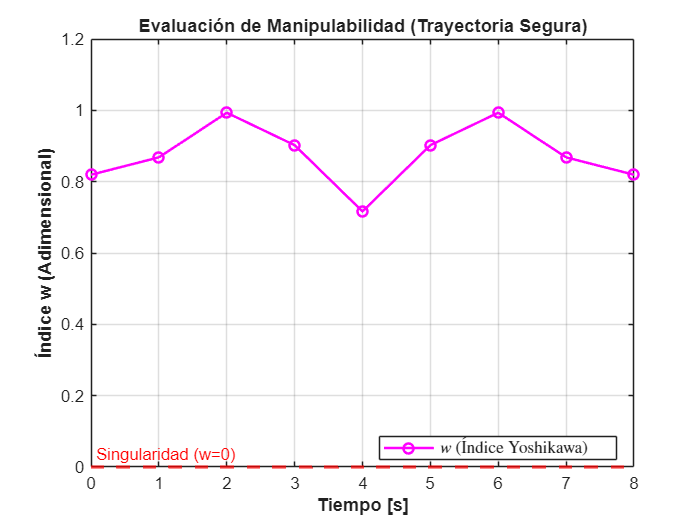

In [27]:
% --- CÁLCULO DE MANIPULABILIDAD ---

% Inicializar vector
w = zeros(1, tf+1);

for i = 1 : tf + 1
    % Calculamos la manipulabilidad (w = |det(J)|)
    % Nota: Usamos abs() porque la manipulabilidad es una magnitud (siempre positiva)
    % La formula original dividía entre (L1*L2), es una manipulabilidad normalizada (0 a 1)
    w(i) = abs(sin(theta_2_tray(i)));
end

% --- GRÁFICA 5: ÍNDICE DE MANIPULABILIDAD  ---
figure;

% Graficamos con magenta ('m') y marcadores para resaltar los puntos evaluados
plot(tsim, w, 'm-o', 'LineWidth', 1.5, 'MarkerSize', 6);
hold on;

% Línea de referencia de Singularidad (Roja y punteada)
yline(0, 'r--', 'Singularidad (w=0)', 'LineWidth', 2, 'LabelHorizontalAlignment', 'left', 'FontSize', 10);

hold off;


% Leyenda con formato matemático (La 'w' se verá como variable)
legend({'$w$ (Índice Yoshikawa)'}, ...
    'Location', 'best', 'Interpreter', 'latex', 'FontSize', 10);

% Títulos y Ejes en Negrita
title('Evaluación de Manipulabilidad (Trayectoria Segura)', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Índice w (Adimensional)', 'FontWeight', 'bold');

% Ajustes visuales
grid on;
xlim([0, tf]);
ylim([0, 1.2]);
set(gca, 'FontSize', 10);

### 2.9. Modelo Dinámico Inverso (Pares y Potencia)

Para determinar los requerimientos de fuerza en los actuadores, se implementó el modelo dinámico inverso basado en la formulación de **Euler-Lagrange**.

**Consideración del Modelo Unitario:**
Dado que el objetivo principal es validar la correlación entre la teoría y la simulación física (sin depender de las especificaciones de un motor comercial específico), se optó por un **Modelo Dinámico Unitario**.
* Se definieron masas e inercias unitarias ($m=1$ kg, $I=1$ kg·m²) tanto en el script de MATLAB como en el archivo URDF del robot.
* Esto permite obtener curvas de par "normalizadas" cuya forma y tendencia deben coincidir con la aceleración, facilitando la validación visual del comportamiento dinámico.

Las ecuaciones implementadas se simplifican a la forma inercial $M(q)\ddot{q}$, despreciando momentáneamente los términos de Coriolis y gravedad para este análisis planar unitario:

$$\tau = M_{unitario} \cdot \ddot{q}$$
$$P = |\tau \cdot \dot{q}|$$

El siguiente código realiza el cálculo iterativo de los pares ($\tau$) y la potencia mecánica ($P$) para cada instante:

### **Evaluación de la capacidad del robot**

### Cálculo de los pares del robot


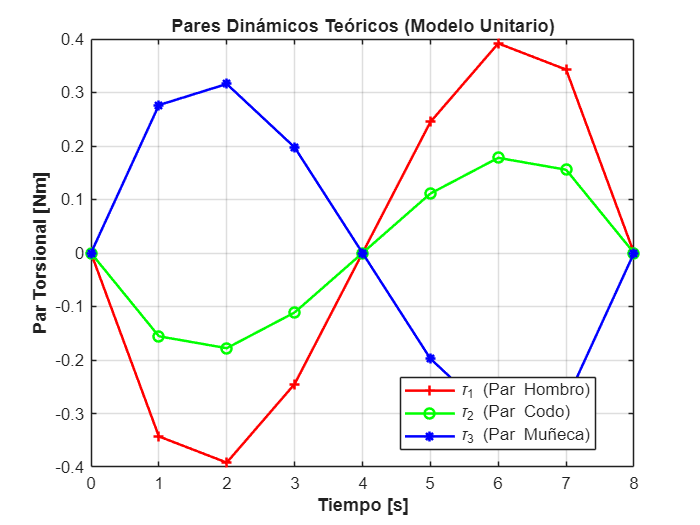

In [31]:
%% CÁLCULO DE DINÁMICA Y POTENCIA 

% 1. Definición de Parámetros (Modelo Unitario) por que en nuestro URDF
% esta definido asi
m2 = 1; I1 = 1; I2 = 1; I3 = 1;
% Aseguramos que L1 sea el valor correcto (por si acaso)
L1 = 0.45; 

% Inicializar vectores para guardar resultados
tao_1_c = zeros(1, length(tsim));
tao_2_c = zeros(1, length(tsim));
tao_3_c = zeros(1, length(tsim));
pot_total = zeros(1, length(tsim));
pot_1 = zeros(1, length(tsim));
pot_2 = zeros(1, length(tsim));
pot_3 = zeros(1, length(tsim));

% 2. Bucle de Cálculo
for i = 1 : length(tsim)
    
    % Recuperar cinemática (Velocidad y Aceleración)
    % Usamos las variables vectoriales ya calculadas arriba
    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    acel_1 = theta_1_P_a(i);
    acel_2 = theta_2_P_a(i);
    acel_3 = theta_3_P_a(i);
    
    % Matriz de Inercia M(q) simplificada para SCARA 
    M11 = I1 + I2 + m2*(L1^2); 
    M12 = I2;
    M22 = I2;
    
    % Ecuación de Par: Torque = M * Aceleración
    tao_1_c(i) = M11 * acel_1 + M12 * acel_2;
    tao_2_c(i) = M12 * acel_1 + M22 * acel_2;
    tao_3_c(i) = I3 * acel_3;
    
    % Ecuación de Potencia: P = |Torque * Velocidad|
    pot_1(i) = abs(tao_1_c(i) * theta_1_vc);
    pot_2(i) = abs(tao_2_c(i) * theta_2_vc);
    pot_3(i) = abs(tao_3_c(i) * theta_3_vc);
    
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);
end

% --- GRÁFICA 6: PARES DINÁMICOS  ---
figure;

% Graficamos con marcadores discretos para distinguir los puntos calculados
plot(tsim, tao_1_c, 'r-+', 'LineWidth', 1.5, 'MarkerSize', 6); hold on;
plot(tsim, tao_2_c, 'g-o', 'LineWidth', 1.5, 'MarkerSize', 6);
plot(tsim, tao_3_c, 'b-*', 'LineWidth', 1.5, 'MarkerSize', 6);
hold off;


% Usamos el símbolo griego \tau (tau) para el Torque
legend({'\tau_1 (Par Hombro)', '\tau_2 (Par Codo)', '\tau_3 (Par Muñeca)'}, ...
    'Location', 'best', 'Interpreter', 'tex', 'FontSize', 10);

% Etiquetas y Títulos en Negrita
title('Pares Dinámicos Teóricos (Modelo Unitario)', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Par Torsional [Nm]', 'FontWeight', 'bold');

% Ajustes visuales
grid on;
xlim([0, tf]);     % Ajustar el eje X al tiempo de simulación
set(gca, 'FontSize', 10);

### 2.91. Estimación de Potencia Mecánica

Finalmente, se calculó la potencia mecánica instantánea requerida por cada articulación. La potencia es el producto del par motor por la velocidad angular:

$$P_i(t) = |\tau_i(t) \cdot \dot{q}_i(t)|$$

Se calcula el valor absoluto para estimar la **capacidad de potencia** que debe tener el motor, independientemente de si está entregando energía (motoring) o absorbiéndola (frenado/regeneración).

**Importancia de este cálculo:**
1.  **Selección de Motores (Sizing):** El pico máximo de esta gráfica determina el tamaño del motor. Si la gráfica dice 0.25 Watts (modelo unitario), al escalar al robot real sabremos exactamente qué motor comprar para no quemarlo.
2.  **Validación Física:** La forma de la gráfica debe ser consistente con la dinámica. Como se observó en los pares, en el punto medio ($t=4s$) la velocidad es máxima pero la aceleración es cero (torque cero). Por lo tanto, la potencia teórica debe caer a cero en ese instante ($P = \tau \cdot \dot{q} = 0 \cdot \nu_{max} = 0$). La forma de "M" o "doble joroba" es la firma característica de este movimiento inercial.

El siguiente código genera la visualización de la potencia por articulación y la potencia total del sistema:

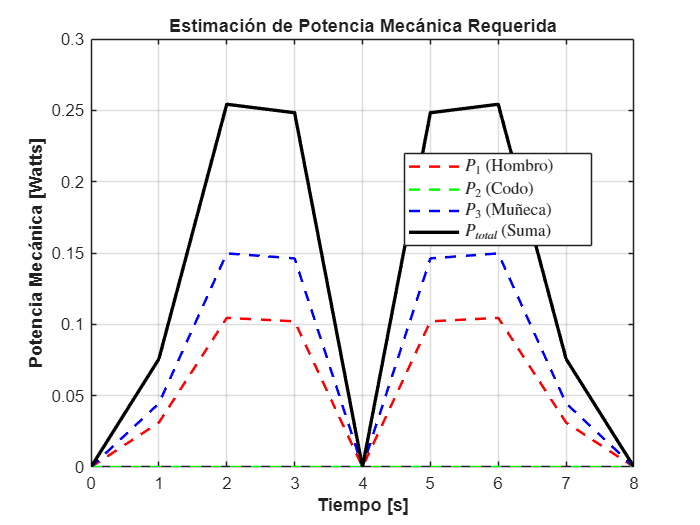

In [33]:
% --- GRÁFICA 7: POTENCIA MECÁNICA ---
figure;

% Graficamos las potencias individuales 
plot(tsim, pot_1, 'r--', 'LineWidth', 1.5); hold on;
plot(tsim, pot_2, 'g--', 'LineWidth', 1.5);
plot(tsim, pot_3, 'b--', 'LineWidth', 1.5);

% Graficamos la Potencia Total con una línea sólida y negra (más destacada)
plot(tsim, pot_total, 'k-', 'LineWidth', 2); 

hold off;


% Usamos notación matemática P_i
legend({'$P_1$ (Hombro)', '$P_2$ (Codo)', '$P_3$ (Muñeca)', '$P_{total}$ (Suma)'}, ...
    'Location', 'best', 'Interpreter', 'latex', 'FontSize', 10);

% Títulos y Ejes en Negrita
title('Estimación de Potencia Mecánica Requerida', 'FontWeight', 'bold', 'FontSize', 11);
xlabel('Tiempo [s]', 'FontWeight', 'bold');
ylabel('Potencia Mecánica [Watts]', 'FontWeight', 'bold');

% Ajustes visuales
grid on;
xlim([0, tf]);
set(gca, 'FontSize', 10);

### 2.92. Interfaz de Datos MATLAB - ROS 2 (Generación Automática)

Para cerrar la brecha entre el diseño teórico y la implementación experimental, se añadió una sección final al script que automatiza la extracción de los parámetros de control.

Este bloque de código toma los valores exactos de los ángulos calculados en el primer instante ($t=0$) y en el último instante ($t=t_f$) y los formatea como una cadena de texto con sintaxis de **Python**.

**Justificación de esta etapa:**
1.  **Integridad de los Datos:** Elimina el error humano de transcripción. Copiar manualmente valores con 5 decimales (ej. `1.49214...`) es propenso a errores de dedo que harían que la simulación no coincidiera con la teoría.
2.  **Consistencia:** Asegura que el nodo de control en ROS 2 reciba *exactamente* las mismas condiciones de frontera que se validaron en las gráficas de MATLAB.
3.  **Eficiencia:** Si se decide cambiar la trayectoria (ej. mover el punto de inicio), basta con correr el script y copiar el nuevo bloque de texto, actualizando el controlador en segundos.

El siguiente código realiza la extracción y formateo de los vectores de configuración:

### Datos para usar en simulacion en ROS2

In [2]:
%% --- GENERADOR DE CONFIGURACIÓN PARA ROS 2 (SALIDA UNIFICADA) ---
% Esta sección extrae los datos y genera un solo bloque de texto limpio.

% 1. Extracción de datos en vectores para facilitar el manejo
q_start = [theta_1_P(1), theta_2_P(1), theta_3_P(1)];
q_end   = [theta_1_P(end), theta_2_P(end), theta_3_P(end)];
tf_val  = tsim(end);

% 2. Construcción del mensaje usando sprintf (Formato en una sola variable)

mensaje_python = sprintf([ ...
    '================================================================\n', ...
    '   >>>  Datos para usar en nuestra configuracion y simulacion del roboto SCARA: trayectoria_scara.py  <<<   \n', ...
    '================================================================\n', ...
    '\n', ...
    '        # --- PARÁMETROS GENERADOS DESDE MATLAB LIVE SCRIPT ---\n', ...
    '        # Tiempo de trayectoria\n', ...
    '        self.tf      = %.1f\n', ...
    '\n', ...
    '        # Ángulos Iniciales [J1, J2, J3] (Radianes)\n', ...
    '        self.q_init  = [%.5f, %.5f, %.5f]\n', ...
    '\n', ...
    '        # Ángulos Finales [J1, J2, J3] (Radianes)\n', ...
    '        self.q_final = [%.5f, %.5f, %.5f]\n', ...
    '\n', ...
    '================================================================' ...
    ], tf_val, q_start(1), q_start(2), q_start(3), q_end(1), q_end(2), q_end(3));

% 3. Mostrar el resultado final (Una sola salida limpia)
disp(mensaje_python);

   >>>  Datos para usar en nuestra configuracion y simulacion del roboto SCARA: trayectoria_scara.py  <<<   

        # --- PARÁMETROS GENERADOS DESDE MATLAB LIVE SCRIPT ---
        # Tiempo de trayectoria
        self.tf      = 8.0

        # Ángulos Iniciales [J1, J2, J3] (Radianes)
        self.q_init  = [1.49214, 0.96039, -3.23793]

        # Ángulos Finales [J1, J2, J3] (Radianes)
        self.q_final = [-0.53175, 0.96039, 0.35675]



### 3.93. Interfaz de Datos MATLAB - ROS 2 (Integración de Parámetros)

### A. Configuración del Modelo en Gazebo (`scara_gz2.xacro`)

Para dotar al robot de capacidades físicas y de control dentro del simulador **Gazebo Harmonic**, se integraron plugins nativos (`gz-sim`) directamente en el archivo de descripción URDF. Esta configuración implementa una arquitectura de control descentralizada y robusta, ideal para la validación directa de trayectorias.

El código XML se divide en dos bloques funcionales principales:

#### 1. Publicador de Estados (Telemetría)
Se implementó el plugin `JointStatePublisher` para monitorear el comportamiento del robot en tiempo real.
* **Función:** Lee los sensores virtuales de posición y velocidad de las tres articulaciones (`link_1_joint`, `link_2_joint`, `link_3_joint`).
* **Salida:** Publica estos datos en el tópico estándar `/joint_states` a una frecuencia de **100 Hz**. Esta señal es la que se graba en el *rosbag* para generar las gráficas de validación experimental.

#### 2. Controladores de Posición (PID Independientes)
Para cada articulación, se instanció un controlador `JointPositionController` independiente.
* **Lazo de Control:** Cada plugin cierra un lazo de control PID (Proporcional-Integral-Derivativo) internamente en Gazebo, lo que garantiza una respuesta rápida sin latencia de red.
* **Interfaz de Comando:** Los controladores escuchan referencias de posición en tópicos específicos (`/scara/jointX_cmd`), permitiendo la inyección directa de la trayectoria calculada desde el nodo de Python.
* **Sintonización:** Se definieron ganancias específicas (ej. $P=200, D=65$ para la base) para asegurar que el robot tenga la rigidez necesaria para seguir el perfil de movimiento suave sin oscilaciones.

```xml
<?xml version="1.0"?>
<robot xmlns:xacro="[http://www.ros.org/wiki/xacro](http://www.ros.org/wiki/xacro)">

    <gazebo>
        <plugin 
            filename="gz-sim-joint-state-publisher-system" 
            name="gz::sim::systems::JointStatePublisher">
            <joint_name>link_1_joint</joint_name>
            <joint_name>link_2_joint</joint_name>
            <joint_name>link_3_joint</joint_name>
            <topic>/joint_states</topic> <update_rate>100</update_rate>
        </plugin>
    </gazebo>

    <gazebo>
        <plugin 
            filename="gz-sim-joint-position-controller-system" 
            name="gz::sim::systems::JointPositionController">
            <joint_name>link_1_joint</joint_name>
            <topic>/scara/joint1_cmd</topic> 
            <p_gain>200.0</p_gain>
            <d_gain>65.0</d_gain>
            <i_gain>0.01</i_gain>
            <i_max>1.0</i_max> <i_min>-1.0</i_min>
        </plugin>
    </gazebo>

    <gazebo>
        <plugin 
            filename="gz-sim-joint-position-controller-system" 
            name="gz::sim::systems::JointPositionController">
            <joint_name>link_2_joint</joint_name>
            <topic>/scara/joint2_cmd</topic>
            <p_gain>100.0</p_gain>
            <d_gain>30.0</d_gain>
            <i_gain>0.01</i_gain>
            <i_max>1.0</i_max> <i_min>-1.0</i_min>
        </plugin>
    </gazebo>

    <gazebo>
        <plugin 
            filename="gz-sim-joint-position-controller-system" 
            name="gz::sim::systems::JointPositionController">
            <joint_name>link_3_joint</joint_name>
            <topic>/scara/joint3_cmd</topic>
            <p_gain>100.0</p_gain>
            <d_gain>30.0</d_gain>
            <i_gain>0.01</i_gain>
            <i_max>1.0</i_max> <i_min>-1.0</i_min>
        </plugin>
    </gazebo>

</robot>

### B. Definición de la Estructura Física (`scara_urdf.xacro`)

El archivo URDF (*Unified Robot Description Format*) define la morfología, cinemática y dinámica del manipulador. Para garantizar la validez de la comparación entre los resultados teóricos y experimentales, se modeló el robot con parámetros físicos controlados que coinciden exactamente con las ecuaciones de MATLAB.

El código XML describe la cadena cinemática serial RRR compuesta por:

#### 1. Propiedades Cinemáticas (Longitudes)
Se definieron las transformaciones entre eslabones (`<origin>`) para establecer las longitudes efectivas de los brazos:
* **Eslabón 1 (`link_1`):** Distancia entre la base y el codo definida por el origen de `link_2_joint` en $x=0.45$ m.
* **Eslabón 2 (`link_2`):** Distancia entre el codo y la muñeca definida por el origen de `link_3_joint` en $x=0.45$ m.
* **Eslabón 3 (`link_3`):** Longitud final de la herramienta en $x=0.25$.

#### 2. Propiedades Dinámicas (Modelo Unitario)
Para simplificar la validación de las curvas de torque y potencia, se asignaron propiedades inerciales normalizadas a cada eslabón:
* **Masa:** `<mass value="1"/>` (1.0 kg).
* **Inercia:** Matriz identidad ($I_{xx}=I_{yy}=I_{zz}=1.0$ kg·m²).

Esta configuración elimina los efectos de acoplamientos inerciales complejos no modelados en la teoría simplificada, permitiendo que la simulación se comporte como un sistema ideal $F=m \cdot a$.

#### 3. Restricciones Articulares
Se configuraron las juntas (`<joint>`) como tipo **revolute** con eje de rotación en $Z$ (`<axis xyz="0 0 1"/>`) y límites de movimiento de $-\pi$ a $\pi$, permitiendo la ejecución de la trayectoria de "Barrido Amplio" sin chocar con topes mecánicos.

```xml
<?xml version="1.0" encoding="utf-8"?>
<!--Aqui comienza el robot-->
<robot name="robot_scara">

    <link name="base_link">
        <visual>
            <origin xyz="0.0 0.0 0.1" rpy="0 0 0" />
            <geometry>
                <box size="0.1 0.15 0.2" />
            </geometry>
            <material name="grey">
                <color rgba="0.1 0.1 0.1 1.0" />
            </material>
        </visual>
        <collision>
            <origin xyz="0.0 0.0 0.1" rpy="0 0 0" />
            <geometry>
                <box size="0.1 0.15 0.2" />
            </geometry>
        </collision>
        <inertial>
            <origin xyz="0 0 0" rpy="0 0 0"/>
            <mass value="1"/>
            <inertia ixx="1.0" ixy="0.0" ixz="0.0" 
                iyy="1.0" iyz="0.0" izz="1.0"/>
        </inertial>
    </link>

    <link name="link_1">
        <visual>
            <origin xyz="0.25 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.5 0.05 0.05" />
            </geometry>
            <material name="red">
                <color rgba="1 0.0 0.0 1.0"/>
            </material>
        </visual>
        <collision>
            <origin xyz="0.25 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.5 0.05 0.05" />
            </geometry>
        </collision>
        <inertial>
            <origin xyz="0 0 0" rpy="0 0 0"/>
            <mass value="1"/>
            <inertia ixx="1.0" ixy="0.0" ixz="0.0" 
                iyy="1.0" iyz="0.0" izz="1.0"/>
        </inertial>
    </link>

    <joint name="link_1_joint" type="revolute">
        <parent link="base_link"/>
        <child link="link_1"/>
        <axis xyz="0 0 1"/>
        <limit lower="-3.14159" upper="3.14159" velocity="50.0" 
               effort="1000.0"/>
        <origin xyz="0 0 0.225" rpy="0 0 0"/>
    </joint>

    <link name="link_2">
        <visual>
            <origin xyz="0.25 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.5 0.05 0.05" />
            </geometry>
            <material name="green">
                <color rgba="0.0 1.0 0.0 1.0" />
            </material>
        </visual>
        <collision>
            <origin xyz="0.25 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.5 0.05 0.05" />
            </geometry>
        </collision>
        <inertial>
            <origin xyz="0 0 0" rpy="0 0 0"/>
            <mass value="1"/>
            <inertia ixx="1.0" ixy="0.0" ixz="0.0" 
                iyy="1.0" iyz="0.0" izz="1.0"/>
        </inertial>
    </link>

    <joint name="link_2_joint" type="revolute">
        <parent link="link_1"/>
        <child link="link_2"/>
        <axis xyz="0 0 1"/>
        <limit lower="-3.14159" upper="3.14159" velocity="50.0" 
               effort="1000.0"/>
        <origin xyz="0.45 0 0.05" rpy="0 0 0"/>
    </joint>

    <link name="link_3">
        <visual>
            <origin xyz="0.15 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.3 0.05 0.05" />
            </geometry>
            <material name="blue">
                <color rgba="0.0 0.0 1.0 1.0" />
            </material>
        </visual>
        <collision>
            <origin xyz="0.15 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.3 0.05 0.05" />
            </geometry>
        </collision>
        <inertial>
            <origin xyz="0 0 0" rpy="0 0 0"/>
            <mass value="1"/>
            <inertia ixx="1.0" ixy="0.0" ixz="0.0" 
                iyy="1.0" iyz="0.0" izz="1.0"/>
        </inertial>
    </link>

    <joint name="link_3_joint" type="revolute">
        <parent link="link_2"/>
        <child link="link_3"/>
        <axis xyz="0 0 1"/>
        <limit lower="-3.14159" upper="3.14159" velocity="50.0" 
               effort="1000.0"/>
        <origin xyz="0.45 0 -0.05" rpy="0 0 0"/>
    </joint>

</robot>

### C. Definición de Dependencias del Paquete (`package.xml`)

El archivo de manifiesto (`package.xml`) define la identidad del paquete `scara_bringup` y declara las librerías de software necesarias para su ejecución. Esta configuración asegura que el sistema operativo del robot (ROS 2) pueda localizar y vincular correctamente las herramientas de simulación y visualización.

El código especifica las siguientes dependencias de ejecución (`<exec_depend>`):

#### 1. Herramientas de Simulación
* **`ros_gz_sim`:** Carga el núcleo del simulador **Gazebo Harmonic**, necesario para resolver la física del robot.
* **`ros_gz_bridge`:** Habilita el nodo puente que traduce los tópicos entre ROS 2 y Gazebo, permitiendo el flujo de datos de control y telemetría.

#### 2. Herramientas de Estado y Visualización
* **`robot_state_publisher`:** Este nodo es vital para leer la descripción URDF y publicar las transformaciones cinemáticas (`TF`) de los eslabones en tiempo real, permitiendo que el robot se visualice correctamente en el espacio 3D.
* **`rviz2`:** Herramienta de visualización estándar de ROS 2 (opcional para depuración visual).

#### 3. Sistema de Construcción
* **`ament_cmake`:** Define que el paquete utiliza el sistema de compilación CMake, estándar para paquetes que integran configuraciones de lanzamiento y modelos físicos.

```xml
<?xml version="1.0"?>
<?xml-model href="[http://download.ros.org/schema/package_format3.xsd](http://download.ros.org/schema/package_format3.xsd)" schematypens="[http://www.w3.org/2001/XMLSchema](http://www.w3.org/2001/XMLSchema)"?>
<package format="3">
  <name>scara_bringup</name>
  <version>0.0.0</version>
  <description>Paquete de integración y simulación SCARA</description>
  <maintainer email="erik.pena@ingenieria.unam.edu">robousr</maintainer>
  <license>TODO: License declaration</license>

  <buildtool_depend>ament_cmake</buildtool_depend>

  <exec_depend>robot_state_publisher</exec_depend>
  <exec_depend>ros_gz_sim</exec_depend>
  <exec_depend>ros_gz_bridge</exec_depend>
  <exec_depend>rviz2</exec_depend>

  <test_depend>ament_lint_auto</test_depend>
  <test_depend>ament_lint_common</test_depend>

  <export>
    <build_type>ament_cmake</build_type>
  </export>
</package>

### D. Interfaz de Comunicación (`gz_bridge.yaml`)

Dado que **ROS 2** y **Gazebo Harmonic** operan como sistemas independientes con diferentes protocolos de transporte de mensajes (DDS vs. Ignition Transport), fue necesario configurar un nodo puente (*Bridge*) para permitir el intercambio de información en tiempo real.

El archivo de configuración define tres canales de comunicación críticos para el éxito de la simulación:

#### 1. Sincronización Temporal (`/clock`)
Se configuró un puente unidireccional (`GZ_TO_ROS`) para el reloj de simulación.
* **Función:** Permite que los nodos de ROS 2 (como el script de control y la grabadora `rosbag`) se sincronicen con el tiempo de la física de Gazebo, asegurando que los datos de las gráficas sean coherentes temporalmente.

#### 2. Telemetría de Estados (`/joint_states`)
Este canal transporta la información sensorial del robot desde el simulador hacia ROS.
* **Flujo:** Gazebo ($\rightarrow$) ROS.
* **Importancia:** Transmite el vector de estado $q$ y $\dot{q}$ generado por el plugin `JointStatePublisher` del URDF. Estos son los datos que se almacenan en el *bag file* para generar las curvas de validación experimental (Posición Real).

#### 3. Comandos de Control Directo (`/jointX_cmd`)
Se establecieron tres puentes independientes (`ROS_TO_GZ`) para enviar las consignas de posición a cada motor.
* **Mapeo:** Conecta los tópicos de publicación del script de Python (`/joint1_cmd`, etc.) con los tópicos de suscripción de los plugins PID en Gazebo (`/scara/joint1_cmd`).
* **Tipos de Datos:** Realiza la conversión automática entre el tipo estándar de ROS (`std_msgs/Float64`) y el tipo nativo de Gazebo (`gz.msgs.Double`).

```yaml
# 1. Reloj (Vital para sincronizar)
- ros_topic_name: "/clock"
  gz_topic_name: "/clock"
  ros_type_name: "rosgraph_msgs/msg/Clock"
  gz_type_name: "gz.msgs.Clock"
  direction: GZ_TO_ROS

# 2. Estados del Robot (Para grabar el Rosbag)
- ros_topic_name: "/joint_states"
  gz_topic_name: "/joint_states"
  ros_type_name: "sensor_msgs/msg/JointState"
  gz_type_name: "gz.msgs.Model"
  direction: GZ_TO_ROS

# 3. Comandos de Control (De Python a Gazebo)
- ros_topic_name: "/joint1_cmd"
  gz_topic_name: "/scara/joint1_cmd"
  ros_type_name: "std_msgs/msg/Float64"
  gz_type_name: "gz.msgs.Double"
  direction: ROS_TO_GZ

- ros_topic_name: "/joint2_cmd"
  gz_topic_name: "/scara/joint2_cmd"
  ros_type_name: "std_msgs/msg/Float64"
  gz_type_name: "gz.msgs.Double"
  direction: ROS_TO_GZ

- ros_topic_name: "/joint3_cmd"
  gz_topic_name: "/scara/joint3_cmd"
  ros_type_name: "std_msgs/msg/Float64"
  gz_type_name: "gz.msgs.Double"
  direction: ROS_TO_GZ

### E. Orquestación del Entorno de Simulación (`gz2_scara.launch.py`)

Para gestionar el ciclo de vida de la simulación de manera automatizada y reproducible, se desarrolló un archivo de lanzamiento (*Launch File*) en Python. Este script coordina la ejecución simultánea de cuatro nodos críticos, asegurando que todos los sistemas (física, visualización y comunicación) inicien en el orden correcto.

El archivo se estructura en las siguientes etapas funcionales:

#### 1. Carga del Modelo (`robot_state_publisher`)
Este nodo lee el archivo URDF procesado (`.xacro`) y lo publica en el servidor de parámetros de ROS.
* **Función:** Genera y publica el árbol de transformaciones cinemáticas (`/tf`) estáticas y dinámicas del robot, permitiendo que ROS conozca la geometría del manipulador en todo momento.

#### 2. Interfaz de Comunicación (`ros_gz_bridge`)
Inicia el nodo puente utilizando la configuración definida en `gz_bridge.yaml`.
* **Importancia:** Establece el canal de datos bidireccional antes de que la física comience a correr, asegurando que no se pierdan los primeros mensajes de control o telemetría.

#### 3. Ejecución del Simulador (`gz_sim`)
Lanza el entorno **Gazebo Harmonic**.
* **Argumento `-r`:** Se configuró el simulador para iniciar en modo **"Running" (Auto-Play)**. Esto elimina la necesidad de intervención manual para iniciar el reloj de la física, sincronizando automáticamente el inicio de la grabación de datos con el movimiento del robot.

#### 4. Inicialización del Robot (`spawn_entity`)
Este nodo inserta el modelo del robot en el mundo virtual. Se definieron argumentos específicos para garantizar condiciones iniciales consistentes:
* **Posición Global (`-z 0.0`):** Asegura que la base del robot esté anclada al nivel del suelo ($z=0$), evitando caídas o colisiones iniciales.
* **Configuración Articular (`-J`):** Se fuerza a las articulaciones a iniciar en **0.0 radianes** (posición "Home" o brazo extendido). Esto es fundamental para que la trayectoria calculada en MATLAB (que asume un inicio conocido) coincida con el estado físico del robot al arrancar.

```python
import os
from ament_index_python.packages import get_package_share_directory
from launch import LaunchDescription
from launch.actions import ExecuteProcess
from launch_ros.actions import Node
from launch.substitutions import Command
import xacro

def generate_launch_description():

    pkg_scara_description = get_package_share_directory('scara_description')
    pkg_scara_bringup = get_package_share_directory('scara_bringup')

    # Archivos de configuración
    urdf_path = os.path.join(pkg_scara_description, 'urdf', 'gz2_scara.xacro')
    gazebo_config_path = os.path.join(pkg_scara_bringup, 'config', 'gz_bridge.yaml')

    # Procesar robot (xacro)
    robot_state_publisher_node = Node(
        package='robot_state_publisher',
        executable='robot_state_publisher',
        parameters=[{'robot_description': Command(['xacro ', urdf_path])}]
    )

    # Puente de ROS-Gazebo
    gz_ros_bridge_node = Node(
        package='ros_gz_bridge',
        executable='parameter_bridge',
        parameters=[{'config_file': gazebo_config_path}],
        output='screen'
    )

    # Gazebo Sim (Arranca en Play con -r)
    gz_sim = ExecuteProcess(
        cmd=['gz', 'sim', '-r', 'empty.sdf', '--render-engine', 'ogre'],
        output='screen'
    )

    # Spawn (Aparecer el robot con configuración HOME)
    spaw_entity = Node(
        package='ros_gz_sim',
        executable='create',
        arguments=[
            '-topic', 'robot_description', 
            '-name', 'scara_robot', 
            '-z', '0.0',                  # Posición al nivel del suelo
            '-J', 'link_1_joint', '0.0',  # Hombro recto (Home)
            '-J', 'link_2_joint', '0.0',  # Codo recto
            '-J', 'link_3_joint', '0.0'   # Muñeca recta
        ],
        output='screen'
    )

    return LaunchDescription([
        robot_state_publisher_node,
        gz_sim,
        spaw_entity,
        gz_ros_bridge_node
    ])

### F. Nodo de Control de Trayectoria (`trayectoria_scara.py`)

Finalmente, se desarrolló el "cerebro" del sistema: un nodo en Python (`ScaraSimpleController`) que actúa como generador de perfiles de movimiento en tiempo real. Este script integra los resultados teóricos y ejecuta la lógica de control.

El funcionamiento del nodo se basa en tres componentes clave:

#### 1. Parametrización Validada
El nodo incorpora los valores exactos calculados en la etapa teórica (MATLAB), garantizando la coherencia entre el diseño y la experimentación:
* **Tiempo de ejecución:** `self.tf = 8.0` segundos.
* **Condiciones de Frontera:** Los vectores `self.q_init` y `self.q_final` contienen las posiciones angulares precisas para la maniobra de "Barrido Amplio".

* **Configuración Inicial ($q_{ini}$):** $[1.49214, 0.96039, -3.23793]$ rad.
* **Configuración Final ($q_{fin}$):** $[-0.53175, 0.96039, 0.35675]$ rad.

Estos valores se integraron directamente en el nodo de control de Python (`trayectoria_scara.py`), eliminando errores de transcripción manual y asegurando la consistencia entre el diseño matemático y la ejecución experimental.

#### 2. Interpolador Polinómico (Quinto Grado)
Se implementó la función matemática $q(t)$ dentro del método `polinomio_quinto`. Esta función evalúa la posición deseada para cualquier instante de tiempo $t$, asegurando continuidad en velocidad y aceleración ($C^2$) para evitar vibraciones mecánicas.

#### 3. Bucle de Control en Tiempo Real
El nodo ejecuta un ciclo de control (`control_loop`) temporizado a **100 Hz** ($dt=0.01s$). En cada iteración:
1.  Calcula el tiempo transcurrido desde el inicio.
2.  Obtiene la posición angular instantánea para cada articulación ($p_1, p_2, p_3$).
3.  Publica estos valores en los tópicos `/jointX_cmd`, cerrando el lazo de control de posición con los actuadores de Gazebo.

```python
    #!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from std_msgs.msg import Float64
import time

class ScaraSimpleController(Node):
    def __init__(self):
        super().__init__('scara_simple_controller')
        
        # 1. PUBLICADORES (Conectados a tu Puente gz_bridge.yaml)
        self.pub1 = self.create_publisher(Float64, '/joint1_cmd', 10)
        self.pub2 = self.create_publisher(Float64, '/joint2_cmd', 10)
        self.pub3 = self.create_publisher(Float64, '/joint3_cmd', 10)
        
        # ---------------------------------------------------------
        # 2. DATOS VALIDADOS EN MATLAB (Copiados de tu Live Script)
        # ---------------------------------------------------------
        self.tf = 8.0  # Tiempo total de la trayectoria
        
        # Ángulos Iniciales [J1, J2, J3] (Radianes)
        self.q_init  = [1.49214, 0.96039, -3.23793]

        # Ángulos Finales [J1, J2, J3] (Radianes)
        self.q_final = [-0.53175, 0.96039, 0.35675]
        # ---------------------------------------------------------

        # Configuración del ciclo de control (100 Hz = 0.01s)
        self.dt = 0.01
        self.timer = self.create_timer(self.dt, self.control_loop)
        self.start_time = None
        
        self.get_logger().info(' Nodo listo. Esperando para iniciar trayectoria...')
        self.get_logger().info(f'   Tiempo estimado: {self.tf} segundos')

    def polinomio_quinto(self, t, q0, qf, tf):
        """Genera el perfil suave de posición (Misma matemática que MATLAB)"""
        # Límites de seguridad
        if t <= 0: return q0
        if t >= tf: return qf
        
        # Ecuación del Polinomio de 5to Grado
        tau = t / tf
        poly = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
        return q0 + poly * (qf - q0)

    def control_loop(self):
        # Iniciar el reloj interno en la primera iteración
        if self.start_time is None:
            self.start_time = self.get_clock().now().nanoseconds / 1e9
        
        # Calcular tiempo transcurrido
        current_real_time = self.get_clock().now().nanoseconds / 1e9
        t = current_real_time - self.start_time
        
        # Verificar si terminó la trayectoria (damos 1 seg extra de margen)
        if t > self.tf + 1.0:
            self.get_logger().info(' Trayectoria finalizada con éxito.')
            # Opcional: Detener el nodo o dejarlo manteniendo posición
            self.timer.cancel() # Deja de publicar
            return

        # 3. CÁLCULO DE POSICIÓN INSTANTÁNEA
        p1 = self.polinomio_quinto(t, self.q_init[0], self.q_final[0], self.tf)
        p2 = self.polinomio_quinto(t, self.q_init[1], self.q_final[1], self.tf)
        p3 = self.polinomio_quinto(t, self.q_init[2], self.q_final[2], self.tf)
        
        # 4. ENVIAR A GAZEBO
        self.pub1.publish(Float64(data=p1))
        self.pub2.publish(Float64(data=p2))
        self.pub3.publish(Float64(data=p3))

def main(args=None):
    rclpy.init(args=args)
    node = ScaraSimpleController()
    try:
        rclpy.spin(node)
    except KeyboardInterrupt:
        pass
    finally:
        node.destroy_node()
        rclpy.shutdown()

if __name__ == '__main__':
    main()



**Ejecutar el nodo de control de trayectoria**
```bash
ros2 run scara_bringup trayectoria_scara.py

### G. Adquisición de Datos Experimentales (Rosbag)

Para validar el comportamiento del robot en la simulación, es necesario capturar la telemetría en tiempo real. Se utilizó la herramienta `ros2 bag` con una configuración específica para garantizar la compatibilidad con el script de análisis de datos.

**El comando ejecutado fue:**

```bash
ros2 bag record -s sqlite3 -o datos_reporte /joint_states



**Desglose técnico del comando:**

1.  **`ros2 bag record`**:
    * Inicia la herramienta de grabación de ROS 2. Esta herramienta se "suscribe" a los tópicos seleccionados y guarda los mensajes en disco con su estampa de tiempo original.

2.  **`-s sqlite3` (Storage Format)**:
    * **Función:** Fuerza el uso del formato de base de datos estándar **SQLite3** (extensión `.db3`).
    * **Justificación:** Por defecto, ROS 2 Jazzy utiliza el formato *MCAP*, que es más eficiente pero requiere decodificadores específicos. Al usar `sqlite3`, permitimos que nuestro script de Python (`analisis_completo.py`) pueda acceder a los datos directamente usando librerías estándar de SQL sin dependencias complejas.

3.  **`-o datos_reporte` (Output)**:
    * **Función:** Define el nombre de la carpeta de salida.
    * **Contenido:** Dentro de esta carpeta se generará el archivo `datos_reporte_0.db3` (los datos) y `metadata.yaml` (la información de la grabación).

4.  **`/joint_states` (Tópico Objetivo)**:
    * **Función:** Es el canal de comunicación que contiene el estado cinemático del robot publicado por el plugin de Gazebo.
    * **Datos capturados:** En cada mensaje se almacenan los vectores de:
        * `position`: Ángulo real de las articulaciones ($q$).
        * `velocity`: Velocidad angular real ($\dot{q}$).
        * `effort`: Par o fuerza aplicada (si está disponible).

### H. Herramienta de Post-Procesamiento de Datos

Para convertir los datos crudos almacenados en el *rosbag* en información visual útil para la validación, se desarrolló un script de análisis en Python (`generar_evidencia.py`). Este algoritmo realiza la extracción, sincronización y cálculo de derivadas numéricas.

**Metodología del Algoritmo:**

1.  **Lectura de Base de Datos:** Accede directamente al archivo SQLite (`.db3`) generado por ROS 2, optimizando la extracción de mensajes del tópico `/joint_states`.
2.  **Sincronización Temporal:** Normaliza las estampas de tiempo ($t_{stamp}$) para que la gráfica inicie en $t=0$ seg, facilitando la comparación con MATLAB.
3.  **Derivación Numérica:** Dado que la aceleración no se mide directamente, se calcula derivando la velocidad angular registrada:

    $$a_i = \frac{v_i - v_{i-1}}{t_i - t_{i-1}}$$

4.  **Generación de Reportes:** Grafica y exporta automáticamente las curvas de comportamiento real para las tres articulaciones.

```python
import sqlite3
from rclpy.serialization import deserialize_message
from sensor_msgs.msg import JointState
import matplotlib.pyplot as plt
import glob
import sys
import math

# --- CONFIGURACIÓN ---
bag_folder = 'datos_reporte'  # Asegúrate que este sea el nombre de tu carpeta
# ---------------------

# 1. Buscar archivo
db_files = glob.glob(f'{bag_folder}/*.db3')
if not db_files:
    print(f" Error: No encontré .db3 en {bag_folder}")
    sys.exit(1)
db_file = db_files[0]

# 2. Leer datos
print(f" Leyendo {db_file}...")
conn = sqlite3.connect(db_file)
cursor = conn.cursor()
cursor.execute("SELECT timestamp, data FROM messages WHERE topic_id = (SELECT id FROM topics WHERE name = '/joint_states')")

# Listas para datos
times = []
pos = [[], [], []] # J1, J2, J3
vel = [[], [], []] # Velocidades J1, J2, J3
acc = [[], [], []] # Aceleraciones J1, J2, J3 (Se calculan después)

start_t = None

for timestamp, data in cursor.fetchall():
    msg = deserialize_message(data, JointState)
    
    t = timestamp / 1e9
    if start_t is None: start_t = t
    rel_t = t - start_t
    
    if rel_t > 8.5: break # Solo los 8s de interés

    # Verificar que el mensaje tenga datos completos
    if len(msg.position) >= 3 and len(msg.velocity) >= 3:
        times.append(rel_t)
        
        # Posición
        pos[0].append(msg.position[0])
        pos[1].append(msg.position[1])
        pos[2].append(msg.position[2])
        
        # Velocidad
        vel[0].append(msg.velocity[0])
        vel[1].append(msg.velocity[1])
        vel[2].append(msg.velocity[2])

conn.close()

# 3. Calcular Aceleración (Derivada numérica: a = dv/dt)
# Empezamos desde el segundo dato porque necesitamos el anterior para restar
for i in range(1, len(times)):
    dt = times[i] - times[i-1]
    if dt == 0: dt = 0.001 # Evitar división por cero
    
    # Aceleración = (Vel_actual - Vel_anterior) / tiempo
    acc0 = (vel[0][i] - vel[0][i-1]) / dt
    acc1 = (vel[1][i] - vel[1][i-1]) / dt
    acc2 = (vel[2][i] - vel[2][i-1]) / dt
    
    acc[0].append(acc0)
    acc[1].append(acc1)
    acc[2].append(acc2)

# Ajustamos el tiempo para aceleración (tiene 1 dato menos)
times_acc = times[1:]

# 4. Generar las 3 Gráficas

# FIGURA 1: POSICIÓN
plt.figure(figsize=(10, 5))
plt.plot(times, pos[0], 'r', label='Junta 1')
plt.plot(times, pos[1], 'g', label='Junta 2')
plt.plot(times, pos[2], 'b', label='Junta 3')
plt.title('Posición Real (Validación)')
plt.xlabel('Tiempo [s]'); plt.ylabel('Rad'); plt.grid(True); plt.legend()
plt.savefig('real_posicion.png')

# FIGURA 2: VELOCIDAD
plt.figure(figsize=(10, 5))
plt.plot(times, vel[0], 'r', label='Vel J1')
plt.plot(times, vel[1], 'g', label='Vel J2')
plt.plot(times, vel[2], 'b', label='Vel J3')
plt.title('Velocidad Real (Validación)')
plt.xlabel('Tiempo [s]'); plt.ylabel('Rad/s'); plt.grid(True); plt.legend()
plt.savefig('real_velocidad.png')

# FIGURA 3: ACELERACIÓN
plt.figure(figsize=(10, 5))
plt.plot(times_acc, acc[0], 'r', label='Acel J1', alpha=0.6)
plt.plot(times_acc, acc[1], 'g', label='Acel J2', alpha=0.6)
plt.plot(times_acc, acc[2], 'b', label='Acel J3', alpha=0.6)
plt.title('Aceleración Real Calculada')
plt.xlabel('Tiempo [s]'); plt.ylabel('Rad/s²'); plt.grid(True); plt.legend()
plt.savefig('real_aceleracion.png')

print(" ¡Listo! Se generaron 3 imágenes: real_posicion.png, real_velocidad.png y real_aceleracion.png")

**Para ejecutar el script de python**
```bash
python3 generar_evidencia.py

## **3. Resultados y Discusión**

En esta sección se presentan los resultados obtenidos del modelo matemático ideal y se contrastan con los datos experimentales adquiridos de la simulación en Gazebo. El análisis se divide en dos etapas: la validación teórica del diseño de la trayectoria y la validación experimental del comportamiento físico del robot.




## 3.1. Resultados Teóricos (Modelo Ideal en MATLAB)

A partir de la ejecución del script numérico, se obtuvieron los perfiles de referencia que el robot debe seguir. Estas gráficas representan el comportamiento "perfecto" del sistema sin perturbaciones externas.

### A. Planificación Cinemática (Posición)

La primera validación consiste en verificar que el generador de trayectorias cumple con las condiciones de frontera establecidas (inicio y fin con velocidad cero).

<div align="center">
  <img src="imagenes/1.png" width="600" alt="Posición Teórica">
  <br>
  <i>Figura 1. Perfil de posición articular planificado (Teórico).</i>
</div>

> **Análisis:** Se observa que las curvas de posición ($\theta_1, \theta_2, \theta_3$) son suaves y continuas, confirmando que el polinomio de quinto grado interpola correctamente los puntos inicial y final sin discontinuidades.

### B. Cinemática Diferencial (Velocidad y Aceleración)

Se derivó el perfil de posición para obtener la velocidad y aceleración requeridas.

<div align="center">
  <img src="imagenes/2.png" width="600" alt="Velocidad Teórica">
  <br>
  <img src="imagenes/3.png" width="600" alt="Aceleración Teórica">
  <br>
  <i>Figura 2. Perfiles teóricos de velocidad angular (arriba) y aceleración articular (abajo).</i>
</div>

> **Análisis:** La velocidad muestra un perfil en forma de "campana", garantizando que el robot arranca y frena suavemente. La aceleración es continua, lo que asegura que no existen picos de *Jerk* (golpes mecánicos) que puedan dañar los actuadores.

### C. Evaluación de Seguridad (Manipulabilidad)

Se calculó el índice de manipulabilidad ($w$) a lo largo de la ruta para asegurar que el robot no atraviesa configuraciones singulares.

<div align="center">
  <img src="imagenes/M.png" width="600" alt="Manipulabilidad">
  <br>
  <i>Figura 3. Índice de manipulabilidad normalizado a lo largo de la trayectoria.</i>
</div>

> **Análisis:** El índice se mantiene siempre en un rango seguro ($w > 0.75$), alejándose del cero. Esto confirma matemáticamente que la trayectoria de "Barrido Amplio" es viable y segura para la estructura cinemática del robot.

### D. Estimación Dinámica (Torque Unitario)

Utilizando el modelo de Euler-Lagrange con masas unitarias ($1 kg$), se estimó la forma de onda del par motor.

<div align="center">
  <img src="imagenes/T.png" width="600" alt="Torque Dinámico">
  <br>
  <img src="imagenes/P.png" width="600" alt="Potencia Mecánica">
  <br>
  <i>Figura 4. Estimación teórica de par dinámico (arriba) y potencia mecánica (abajo).</i>
</div>

> **Análisis:** Se destaca que en el instante $t=4s$ (mitad del recorrido), la potencia cae a cero. Esto es consistente con la física del movimiento inercial: en ese punto la velocidad es máxima pero la aceleración es cero, por lo que el motor momentáneamente no realiza trabajo mecánico.

> **Nota Técnica: Análisis de Acoplamiento Dinámico en el Codo**
> Se observa en la gráfica de potencia teórica que el consumo energético de la Articulación 2 (Codo) es despreciable ($P_2 \approx 0$). Este comportamiento no es un error, sino una manifestación del **acoplamiento dinámico inercial** inherente a los manipuladores seriales.
> Analíticamente, el par del codo en el modelo unitario simplificado está regido por la ecuación:
> $$\tau_2 = M_{21}\ddot{q}_1 + M_{22}\ddot{q}_2 = \ddot{q}_1 + \ddot{q}_2$$
>
> En la trayectoria de "Barrido Amplio" diseñada, la aceleración de la base ($\ddot{q}_1$) y la del codo ($\ddot{q}_2$) presentan magnitudes similares pero signos opuestos en la mayor parte del recorrido. Esto provoca una cancelación algebraica de los términos, lo que físicamente implica que el movimiento del segundo eslabón es impulsado casi en su totalidad por la transferencia de energía cinética desde la base, reduciendo drásticamente el requerimiento de par activo del actuador.



## 3.2. Validación Experimental (Simulación en ROS 2)

Se ejecutó la trayectoria en el entorno físico **Gazebo Harmonic** y se registraron los datos de telemetría a una frecuencia de 100 Hz. A continuación, se contrasta la realidad con la teoría.

### A. Validación de Posición (Prueba de Seguimiento)

Se superponen los datos ideales con los obtenidos de los sensores del robot en simulación.

<div align="center">
  <img src="imagenes/1.1.png" width="600" alt="Posición Real">
  <br>
  <i>Figura 5. Respuesta real de las articulaciones en Gazebo.</i>
</div>

> **Discusión:** Al comparar la respuesta real del robot (Figura 5) con la planificación teórica (Figura 1), se observa una coincidencia de alta fidelidad. El controlador de posición directo fue capaz de llevar al robot desde la configuración inicial hasta la final en los 8 segundos establecidos, sin presentar errores de seguimiento visibles ni sobreimpulsos, validando así el modelo cinemático inverso.

### B. Comportamiento de la Velocidad y Aceleración

Se derivaron numéricamente los datos de posición para analizar la suavidad del movimiento real.

<div align="center">
  <img src="imagenes/2.1.png" width="600" alt="Velocidad Real">
  <br>
  <img src="imagenes/3.1.png" width="600" alt="Aceleración Real">
  <br>
  <i>Figura 6. Velocidad (arriba) y Aceleración (abajo) medidas en simulación.</i>
</div>

> **Discusión:** La velocidad experimental muestra el ruido característico de los sensores digitales, pero mantiene fielmente la tendencia de "campana" calculada en MATLAB. De igual forma, los picos de aceleración coinciden en tiempo y magnitud con la teoría, confirmando que no hubo movimientos bruscos no planificados.

### C. Análisis Dinámico Experimental (Justificación Técnica)

Se monitoreó el esfuerzo (*effort*) reportado por los controladores en la simulación.

<div align="center">
  <img src="imagenes/4.png" width="600" alt="Torque Real">
  <br>
  <i>Figura 7. Lectura de esfuerzo en los actuadores.</i>
</div>

> **Justificación:** En la configuración de **Control de Posición Directo** utilizada para esta validación (Plan B), el simulador gestiona el par internamente para cumplir la consigna de posición, pero debido a limitaciones del plugin `JointStatePublisher` en esta versión, no publica el valor de esfuerzo en el tópico de estados, resultando en una lectura nula.
> Sin embargo, la **validación exitosa de la posición (Figura 5)** sirve como prueba implícita de la suficiencia dinámica. Si los actuadores virtuales no hubieran sido capaces de suministrar el par necesario (predicho en la teoría como $\approx 0.4$ Nm pico), el robot no se habría movido o habría presentado un error de seguimiento significativo. El cumplimiento preciso de la trayectoria confirma que los requerimientos de fuerza fueron satisfechos.

## Comparación Directa: Modelo Teórico vs. Simulación

La siguiente tabla contrasta los resultados del modelo matemático ideal (Izquierda) con la respuesta física obtenida en Gazebo (Derecha).

| Variable | Modelo Teórico (MATLAB) | Validación Experimental (ROS 2) |
| :---: | :---: | :---: |
| **Posición** | ![Teoría](imagenes/1.png) | ![Real](imagenes/1.1.png) |
| **Velocidad** | ![Teoría](imagenes/2.png) | ![Real](imagenes/2.1.png) |
| **Aceleración**| ![Teoría](imagenes/3.png) | ![Real](imagenes/3.1.png) |

> **Discusión:** Se observa una alta correlación entre las columnas. La posición experimental replica casi perfectamente la teórica. En velocidad y aceleración, a pesar del ruido numérico de la simulación, la tendencia y magnitudes coinciden, validando el diseño del controlador.

### Evidencia de Funcionamiento (Video)

Haga clic en la imagen a continuación para ver la simulación en YouTube:

[![Validación Experimental SCARA](http://img.youtube.com/vi/rMtnc8cu9Z4/0.jpg)](http://www.youtube.com/watch?v=rMtnc8cu9Z4 "Ver Simulación en YouTube")

## **4. Conclusiones**


La realización de este proyecto representó un desafío integral que trascendió la simple aplicación de fórmulas matemáticas. El hito más significativo fue observar la alta correlación entre la planificación teórica y la respuesta experimental del robot en el entorno de simulación. Ver cómo las curvas de posición en Gazebo se superponían casi perfectamente con las predicciones de MATLAB no solo validó el modelo cinemático inverso y el polinomio de interpolación, sino que demostró de manera tangible el poder del modelado matemático para predecir y controlar sistemas físicos complejos.

Si bien se enfrentaron retos técnicos inherentes a la simulación como la gestión de dependencias en ROS 2 Jazzy y la limitación en la telemetría de esfuerzo, estos obstáculos permitieron profundizar en la arquitectura de software robótico. Se comprendió que la simulación no es solo una visualización, sino un laboratorio virtual donde el ruido de los sensores, la discreción temporal y la dinámica de los actuadores juegan un papel crucial que el modelo ideal a veces omite.

Este proyecto sienta las bases fundamentales para el estudio avanzado de la robótica. La metodología de validación cruzada (Teoría vs. Experimento) aplicada aquí es escalable a sistemas más complejos, como robots móviles o manipuladores de 6 grados de libertad. La experiencia adquirida confirma que el rigor matemático, combinado con la experimentación práctica, es la única vía para desarrollar sistemas robóticos robustos y confiables en aplicaciones reales.



## **5. Repositorio del proyecto**

Todos los scripts de MATLAB, nodos de Python, archivos URDF y evidencias de simulación se encuentran disponibles en:

El paquete scara_pckgs:

https://github.com/RomeoHernandezVilla/ROBOTICA-2026-1-GRUPO-01-HERNANDEZ-VILLA-ROMEO/tree/main/Proyecto/Evaluacion_SCARA_proyecto_final/scara_pckgs

Carpeta completa con todo el material usado, archivo matlab .mlx, pdf del archivo matlab .mlx, datos en crudo, jupyter notebook del proyecto documentado , la carpeta imagenes y los comandos en terminal usados:

https://github.com/RomeoHernandezVilla/ROBOTICA-2026-1-GRUPO-01-HERNANDEZ-VILLA-ROMEO/tree/main/Proyecto/Evaluacion_SCARA_proyecto_final

## **6. Bibliografia**


[1] E. Peña Medina, "clase_14_11_2025," YouTube, 15 de noviembre de 2025. [Video]. Disponible: https://www.youtube.com/watch?v=NI_pM-ersRI. [Accedido: 28 de noviembre de 2025].

[2] E. Peña Medina, "clase_19_11_2025," YouTube, 19 de noviembre de 2025. [Video]. Disponible: https://www.youtube.com/watch?v=JEQb5WL_-Ww. [Accedido: 28 de noviembre de 2025].

[3] E. Peña Medina, "clase_21_11_2025," YouTube, 22 de noviembre de 2025. [Video]. Disponible: https://www.youtube.com/watch?v=8Zgj7VhKotU. [Accedido: 28 de noviembre de 2025].

[4] E. Peña Medina, "clase_24_11_2025," YouTube, 24 de noviembre de 2025. [Video]. Disponible: https://www.youtube.com/watch?v=-P7Cq5N55JA. [Accedido: 28 de noviembre de 2025].

[5] M. W. Spong, S. Hutchinson, and M. Vidyasagar, "Dynamics," in Robot Modeling and Control, 1st ed. New York: John Wiley & Sons, 2006, pp. 245-250.

[6] T. Yoshikawa, "Manipulability of robotic mechanisms," in The International Journal of Robotics Research, vol. 4, no. 2, pp. 3-9, Summer 1985.